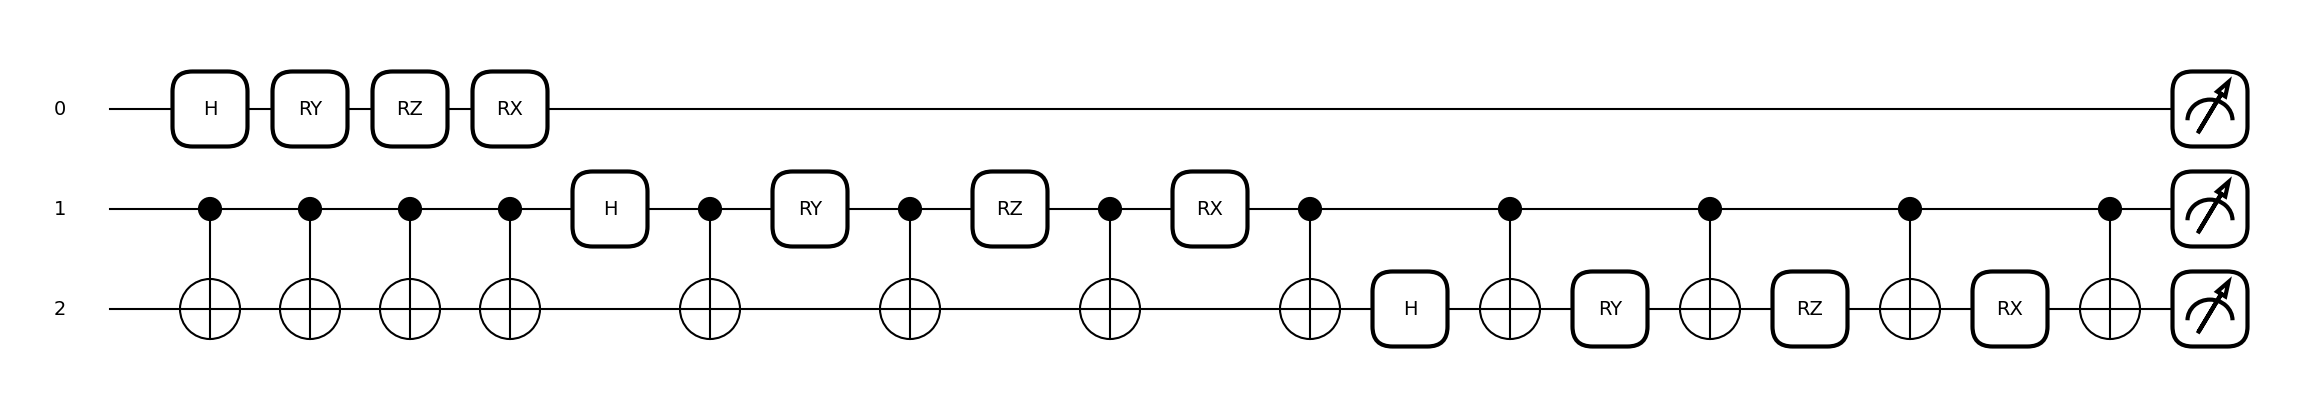

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\1002-ORIGIN-2D electronic properties2.csv",encoding='ISO-8859–1')      
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]



# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x)

# Quantum setup
n_qubits = 3
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [2]:
y_train=(y)

In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)


,kernel,'precomputed'
,degree,3
,gamma,2.0881963569756823
,coef0,0.0
,tol,0.001
,C,977
,epsilon,0.07491851902055541
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


train r^2: 0.5296450412600568
train MAE 0.6782853985840589
train RMSE: 0.9464770490878983


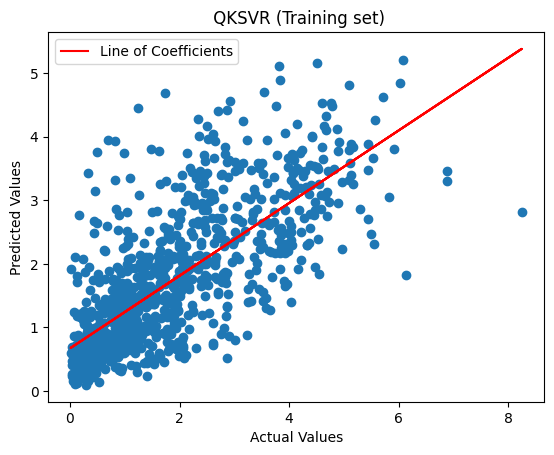

In [4]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QKSVR (Training set)")#title
plt.legend()

In [5]:
df_true50=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-50-EXTERNAL DATA.csv",encoding='ISO-8859–1')    
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df_true50['Band gap ']

# defining target
x2=df_true50[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [1.1220902  0.82649776 0.67941654 1.32643452 1.03678883 1.32116387
 1.34910141 0.70304191 3.52047554 2.31120596 0.75814815 0.81200943
 1.89047263 0.28054365 0.71044945 0.23763117 1.28074895 0.61973015
 0.40937401 3.9283963  1.44234753 2.53741472 0.54703497 2.25574646
 1.65987742 1.52801369 0.65736362 0.52780768 2.51062162 2.96465829
 4.32095418 0.4574351  0.64584455 0.87569413 1.20566132 0.7949195
 0.11119929 3.6387953  3.44834815 0.93185892 2.29202878 1.71068843
 0.60670231 0.60889714 1.26301882 1.39964681 1.62649494 0.89929396
 1.93441614 4.88186769]


Model evaluation - Test Set:
r^2: 0.4432569941543033
MAE 0.635354271767208
RMSE: 0.9414525324360252


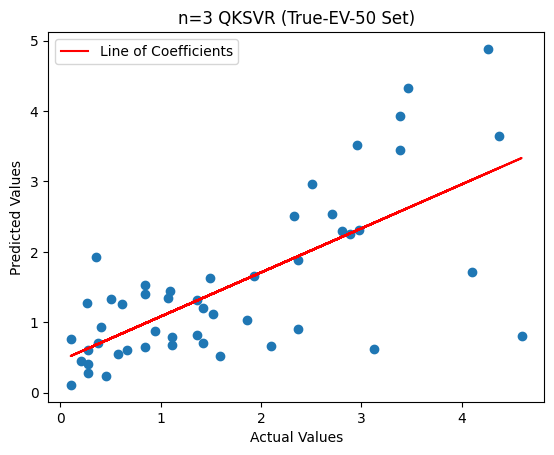

In [6]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y2, y_pred2)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y2, y_pred2)), (-0.2, 13.2))
plt.title("n=3 QKSVR (True-EV-50 Set)")#title
plt.legend()

In [7]:
df3=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-100-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [0.91601766 2.37180404 1.30619663 1.38688259 4.27567253 1.99275021
 4.45933946 1.40584617 0.65399002 0.61767011 0.24126546 0.86429488
 0.73740319 0.37281833 0.91972039 2.14782248 0.90891148 0.79006841
 3.03614146 2.36713142 2.94817624 0.78307013 0.82090578 3.95642931
 1.01252477 2.14157453 3.24611926 3.79984791 1.74369384 2.1182286
 1.81713452 4.44051774 2.72304997 2.60259079 2.46338395 0.80887947
 1.07063    0.84027933 1.57365846 1.41969561 2.56181652 1.39209083
 0.59537536 1.27760595 2.21386676 1.97340736 2.13447095 0.55337028
 0.69594808 1.13328042 0.3410756  0.85747059 0.34540651 0.70785259
 0.24506457 1.20678364 3.27902721 0.84506696 0.75880674 1.7334718
 1.52727107 1.5068308  1.25333459 1.74096248 0.46167792 1.83573801
 2.88727997 1.42072765 2.34307104 3.79189069 0.81147499 3.55244265
 0.8806135  1.51759244 0.99332076 3.4798822  2.09567453 0.8271887
 0.80490393 0.9947604  0.26242886 0.41634927 0.27285718 1.46375528
 0.80838512 0.51184847 2.01264782 0.97335235 3.

Model evaluation - Test Set:
r^2: 0.5547712930923365
MAE 0.6788034314270271
RMSE: 1.0581944963547072


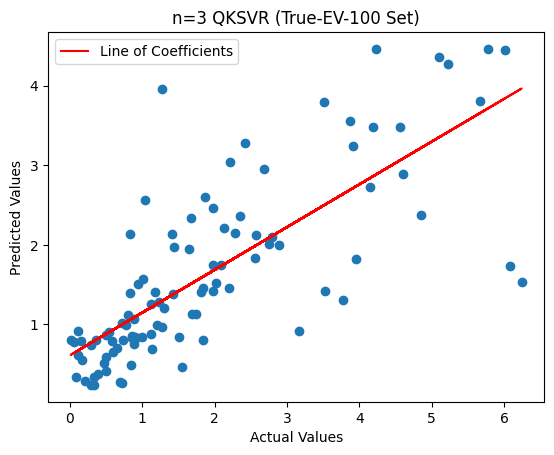

In [8]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y3, y_pred3)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y3, y_pred3)), (-0.2, 13.2))
plt.title("n=3 QKSVR (True-EV-100 Set)")#title
plt.legend()

In [9]:

df4=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-250-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [1.71514796 2.56737165 1.01984023 0.96475874 1.14195761 1.70512147
 2.64199723 0.65868694 0.78439418 4.72190271 0.46882137 3.855731
 0.86397838 0.54205235 0.48633551 0.6703292  2.79208329 0.78540196
 0.8500453  1.37611487 3.9475522  0.79327014 3.75811309 1.30543652
 1.79897304 1.59216343 3.53388132 1.32695496 3.2946032  2.9898221
 1.06018654 1.09231011 1.35459423 0.6610439  3.02512611 1.00536581
 0.74067146 0.92355899 1.74710174 1.98534233 0.78033373 0.94803937
 0.78945537 1.54220811 1.9336179  3.35998843 0.64509634 1.25749012
 2.01097353 0.51011676 0.26206921 2.31758595 0.45153512 0.7088711
 0.83428863 3.50938411 1.00475274 1.60461143 1.33304818 2.03353967
 2.60656908 1.44395209 2.41734994 0.83501916 0.7201199  1.9363573
 0.72182891 0.66251685 3.0069032  1.36410252 0.46555578 3.87530285
 2.24636644 0.75979011 1.53147169 0.77793239 0.57146211 0.98177024
 0.80451273 0.82707179 1.03932279 0.30811329 1.29775421 4.52621698
 2.16348793 1.9118741  1.88656793 4.19136605 0.86

Model evaluation - Test Set:
r^2: 0.5082128853911836
MAE 0.7058673823092069
RMSE: 1.0258820586792727


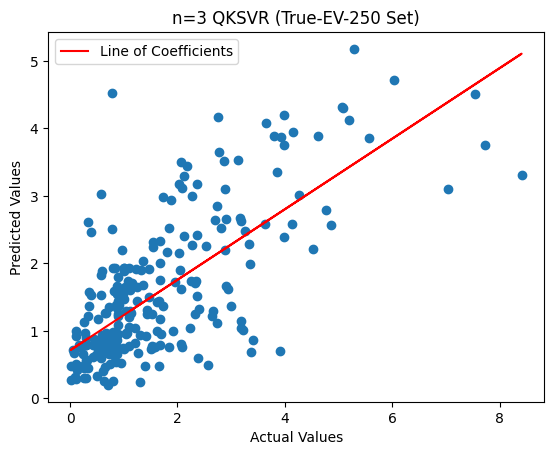

In [10]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y4, y_pred4)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y4, y_pred4)), (-0.2, 13.2))
plt.title("n=3 QKSVR (True-EV-250 Set)")#title
plt.legend()

In [11]:
df5=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-400-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [1.1220902  0.82649776 0.67941654 1.32643452 1.03678883 1.32116387
 1.34910141 0.70304191 3.52047554 2.31120596 0.75814815 0.81200943
 1.89047263 0.28054365 0.71044945 0.23763117 1.28074895 0.61973015
 0.40937401 3.9283963  1.44234753 2.53741472 0.54703497 2.25574646
 1.65987742 1.52801369 0.65736362 0.52780768 2.51062162 2.96465829
 4.32095418 0.4574351  0.64584455 0.87569413 1.20566132 0.7949195
 0.11119929 3.6387953  3.44834815 0.93185892 2.29202878 1.71068843
 0.60670231 0.60889714 1.26301882 1.39964681 1.62649494 0.89929396
 1.93441614 4.88186769 0.91601766 2.37180404 1.30619663 1.38688259
 4.27567253 1.99275021 4.45933946 1.40584617 0.65399002 0.61767011
 0.24126546 0.86429488 0.73740319 0.37281833 0.91972039 2.14782248
 0.90891148 0.79006841 3.03614146 2.36713142 2.94817624 0.78307013
 0.82090578 3.95642931 1.01252477 2.14157453 3.24611926 3.79984791
 1.74369384 2.1182286  1.81713452 4.44051774 2.72304997 2.60259079
 2.46338395 0.80887947 1.07063    0.84027933 

Model evaluation - Test Set:
r^2: 0.5179243572195649
MAE 0.6902872557709122
RMSE: 1.023966188813204


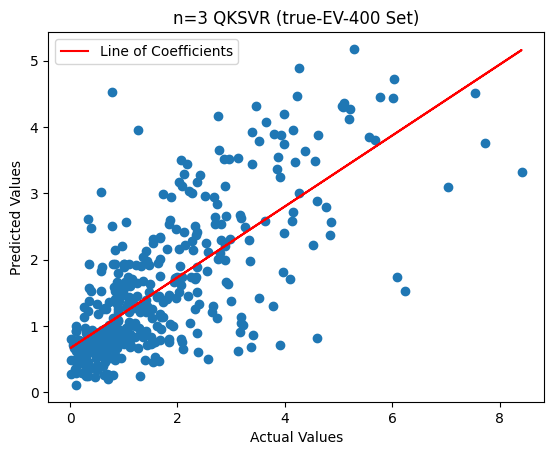

In [12]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y5, y_pred5)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y5, y_pred5)), (-0.2, 13.2))
plt.title("n=3 QKSVR (true-EV-400 Set)")#title
plt.legend()